# Model 1: Audio2Midi Melody Transcription

In [4]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 37.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.10-py3-none-any.whl size=5592286 sha256=fe3511cd1396d9a4f13a253e558186216069c49a3788e330d5c6cfdf54e77b63
  Stored in directory: /root/.cache/pip/wheels/e6/95/ac/15ceaeb2823b04d8e638fd1495357adb8d26c00ccac9d7782e
Successfully built pretty_midi


In [5]:
import torch
import torch.nn as nn

class LSTMMidi(nn.Module):
    def __init__(self, input_size=1025, hidden_size=2000, proj_size=500, output_size=601,
                 num_layers=1, dropout=0.2, device='cuda'):
        """
        LSTM-RNN for melody extraction with harmonic sum loss as described in the paper

        Args:
            input_size: dimension of input features
            hidden_size: number of LSTM cells
            proj_size: size of projection layer (500)
            output_size: number of pitch classes (600 pitch bins + 1 for no melody = 601)
            num_layers: number of LSTM layers
            dropout: dropout probability
            device: 'cuda' or 'cpu'
        """
        super(LSTMMidi, self).__init__()

        self.hidden_size = hidden_size
        self.proj_size = proj_size
        self.output_size = output_size
        self.device = device
        self.projection = nn.Linear(hidden_size, proj_size)

        # Using LSTM with projection as described in the paper
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)

        # Output layer (projection to pitch classes)
        self.fc = nn.Linear(proj_size, output_size)

        # Initialize weights (as mentioned in paper: uniform [-0.05, 0.05])
        self._init_weights()

    def _init_weights(self):
        """Initialize weights uniformly between -0.05 and 0.05"""
        for param in self.parameters():
            nn.init.uniform_(param, -0.05, 0.05)

    def forward(self, x):
        """
        Forward pass

        Args:
            x: input sequence [batch_size, seq_len, input_size]

        Returns:
            y_pred: pitch prediction probabilities [batch_size, seq_len, output_size]
        """
        # LSTM with projection layer
        output, _ = self.lstm(x)
        output = self.projection(output)

        # Apply fully connected layer
        y_pred = self.fc(output)

        return y_pred

Using  cpu :
torch.Size([1, 2958, 601])
[[74  0 75 ... 74 73 59]]


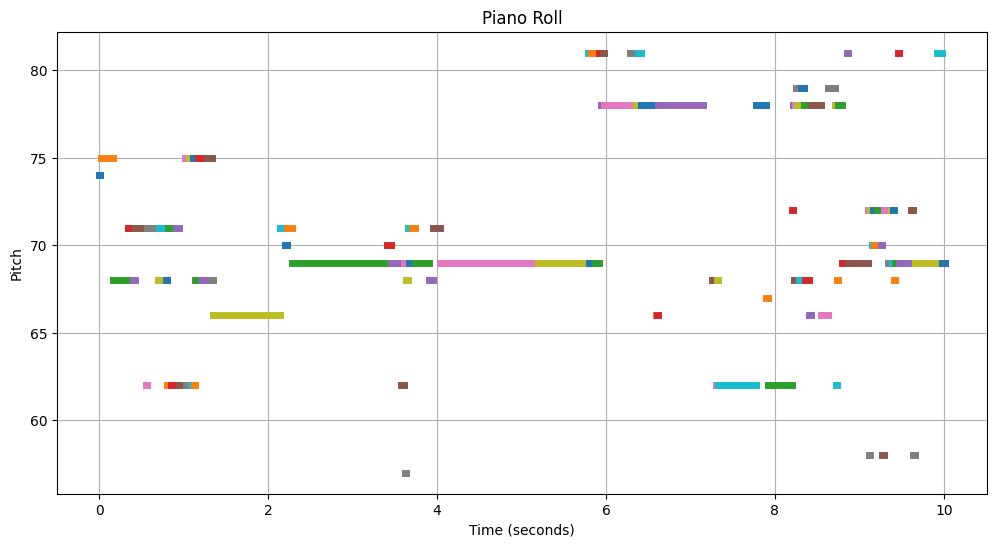

'./output.mid'

In [18]:
#insert pretrained model and test
import torch
import torchaudio
import pretty_midi
import matplotlib.pyplot as plt
import subprocess


device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

def save_wav(midi_filepath, output_filepath='output.wav'):
    wav_filepath = output_filepath
    process = subprocess.Popen(f"fluidsynth soundfont.sf -g 1.0 -r 44100 --quiet --no-shell {midi_filepath} -T wav -F {wav_filepath} > /dev/null", shell=True)
    process.wait()
    return wav_filepath

def spectrogram(audio_path):
    '''
    Create the mel spectrogram for the audio file using torchaudio
    args: path to the audio file
    return: mel spectrogram with shape (channels, mel_bins, num_frames)
    '''

    hop_length = 160
    nfft = 2048
    win_length = 768
    sample_rate = 16000

    waveform, sr = torchaudio.load(audio_path) #original sr = 44100
    waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=sample_rate)(waveform) #resample to 16000 Hz - (channels, time_steps)

    spec = torchaudio.transforms.Spectrogram(n_fft=nfft, hop_length=hop_length, win_length=win_length)(waveform)

    # Apply log compression (helps with dynamic range)
    spec = torch.log1p(spec)
    spec = (spec - spec.mean()) / (spec.std() + 1e-8) #normalization

    return spec

def convert_predictions_to_midi(predictions, output_file='output.mid', fs=16000, hop_length=160, velocity=100):
    """
    Convert model predictions of melody notes to a MIDI file

    Args:
        predictions: numpy array of pitch predictions in the form [[74 0 75 ... 74 73 59]]
        output_file: path to save the MIDI file (default: 'output.mid')
        fs: sample rate of original audio (default: 16000 Hz)
        hop_length: hop length used in feature extraction (default: 160)
        velocity: velocity value for MIDI notes (default: 100)

    Returns:
        pretty_midi.PrettyMIDI object containing the melody
    """

    # Flatten the predictions if they're in a 2D array
    if predictions.ndim > 1:
        predictions = predictions.flatten()

    # Create a PrettyMIDI object
    midi = pretty_midi.PrettyMIDI()

    # Create an Instrument instance for piano
    instrument = pretty_midi.Instrument(program=0)  # Program 0 is acoustic grand piano

    # Convert frame indices to time in seconds
    time_per_frame = hop_length / fs

    # Process the predictions
    current_note = None
    note_start_time = 0

    for i, pitch in enumerate(predictions):
        time_in_seconds = i * time_per_frame

        # Handle different cases
        if pitch == 0:  # 0 represents silence/no melody
            # End current note if there was one
            if current_note is not None:
                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=int(current_note),
                    start=note_start_time,
                    end=time_in_seconds
                )
                instrument.notes.append(note)
                current_note = None
        else:
            # Regular MIDI notes
            # If it's a continuation of the same note, extend it
            if current_note == pitch:
                continue

            # End previous note if there was one
            if current_note is not None:
                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=int(current_note),
                    start=note_start_time,
                    end=time_in_seconds
                )
                instrument.notes.append(note)

            # Start new note (only if it's in valid MIDI range 0-127)
            if 0 <= pitch <= 127:
                current_note = pitch
                note_start_time = time_in_seconds

    # Add the final note if needed
    if current_note is not None:
        note = pretty_midi.Note(
            velocity=velocity,
            pitch=int(current_note),
            start=note_start_time,
            end=len(predictions) * time_per_frame
        )
        instrument.notes.append(note)

    # Add the instrument to the PrettyMIDI object
    midi.instruments.append(instrument)

    # Write out the MIDI data
    midi.write(output_file)

    return midi


# Optional: visualize the notes
def plot_piano_roll(midi_file, start_time=0, end_time=10):
    """Plot a piano roll visualization of the MIDI file"""
    plt.figure(figsize=(12, 6))
    for instrument in midi_file.instruments:
        for note in instrument.notes:
            if start_time <= note.start <= end_time:
                plt.plot([note.start, note.end], [note.pitch, note.pitch], linewidth=5)

    plt.xlabel('Time (seconds)')
    plt.ylabel('Pitch')
    plt.title('Piano Roll')
    plt.grid(True)
    plt.show()



def test_audio(audio_path, checkpoint_path, device='cpu'):

    model = LSTMMidi().to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    spec = spectrogram(audio_path).to(device)
    spec = spec.permute(0,2,1).to(device) #change the shape to (batch_size, time_steps, freq_bins)

    # Forward pass
    with torch.no_grad():
        outputs = model(spec)

    # outputs = outputs.permute(0, 2, 1)
    print(outputs.shape)

    # Get predicted pitch indices
    pred_pitch = torch.argmax(outputs, dim=2).cpu().numpy()
    return pred_pitch

if __name__ == '__main__':

    # use GPU if available, otherwise, use CPU
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    print("Using ", device , ":")

    audio_path = "/content/Strauss-BlueDanube-ex1.wav"
    checkpoint_path = "/content/best_model.pth"
    output_midi_path = "./output.mid"
    output_wav_path = "./output.wav"

    # Test the audio file
    predictions = test_audio(audio_path, checkpoint_path, device=device)

    print(predictions)

    # Convert to MIDI
    midi_file = convert_predictions_to_midi(predictions, output_midi_path)

   # Visualize the MIDI
    plot_piano_roll(midi_file)

    save_wav(output_midi_path)
    display(output_midi_path)

# Model 2: ImprovNet

In [7]:
import os

# If exists don't clone
if not os.path.exists('/content/improvnet'):
  !git clone https://github.com/keshavbhandari/improvnet.git
  %cd improvnet
else:
  %cd improvnet

Cloning into 'improvnet'...
remote: Enumerating objects: 477, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 477 (delta 142), reused 171 (delta 95), pack-reused 236 (from 2)
Receiving objects: 100% (477/477), 165.52 MiB | 27.15 MiB/s, done.
Resolving deltas: 100% (256/256), done.
Updating files: 100% (90/90), done.
/content/improvnet


In [8]:
!apt install fluidsynth
!pip install -r requirements.txt

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [9]:
import gdown

data_url = 'https://drive.google.com/uc?id=11H3y2sFUFldf6nS5pSpk8B-bIDHtFH4K'
data_out = '/content/improvnet/artifacts.zip'
gdown.download(data_url, data_out, quiet=False)

!unzip -q /content/improvnet/artifacts.zip -d /content/improvnet/

Downloading...
From (original): https://drive.google.com/uc?id=11H3y2sFUFldf6nS5pSpk8B-bIDHtFH4K
From (redirected): https://drive.google.com/uc?id=11H3y2sFUFldf6nS5pSpk8B-bIDHtFH4K&confirm=t&uuid=58fd381b-66f2-4a09-a1d9-8f190f8d78d1
To: /content/improvnet/artifacts.zip
100%|██████████| 2.91G/2.91G [00:37<00:00, 77.5MB/s]


In [10]:
import subprocess

def save_wav(midi_filepath):
    wav_filepath = midi_filepath.replace('.mid', '.wav')
    process = subprocess.Popen(f"fluidsynth soundfont.sf -g 1.0 -r 44100 --quiet --no-shell {midi_filepath} -T wav -F {wav_filepath} > /dev/null", shell=True)
    process.wait()
    return wav_filepath

In [11]:
# @title Run this to generate the YAML config

import ipywidgets as widgets
from IPython.display import display
import yaml
import subprocess
from collections import OrderedDict

# List of default corruption types for different passes
default_corruption_types = [
    'skyline', 'skyline', 'skyline'
]

default_corruption_rates = [1.0, 1.0, 1.0]

# Define styles to increase the width of the description labels
description_style = {'description_width': '150px'}  # Adjust the width as needed

# Text boxes for generation parameters
convert_from = widgets.Dropdown(options=['jazz', 'classical'], value='classical', description='Convert From:', style=description_style)
convert_to = widgets.Dropdown(options=['jazz', 'classical'], value='jazz', description='Convert To:', style=description_style)
midi_file_path = widgets.Text(value='/content/melody.mid', description='MIDI Path:', style=description_style)
wav_file_path = widgets.Text(value='', description='WAV Path:', style=description_style)
novel_peaks_pct = widgets.FloatText(value=0.0, description='Preseravtion Ratio:', style=description_style)
temperature = widgets.FloatText(value=1.0, description='Temperature:', style=description_style)
context_before = widgets.IntText(value=5, description='Context Before:', style=description_style)
context_after = widgets.IntText(value=2, description='Context After:', style=description_style)
t_segment_start = widgets.IntText(value=0, description='T Segment Start:', style=description_style)
t_segment_stop = widgets.IntText(value=-1, description='T Segment Stop:', style=description_style)
end_original = widgets.Checkbox(value=True, description='End Original', style=description_style)
use_constraints = widgets.Checkbox(value=True, description='Use Constraints', style=description_style)
reharmonize = widgets.Checkbox(value=False, description='Reharmonize', style=description_style)
write_intermediate_passes = widgets.Checkbox(value=True, description='Write Intermediate Passes', style=description_style)

# UI to input the number of passes
num_passes = widgets.IntText(value=3, description='Number of Passes:', style=description_style)
pass_widgets = []

# Define pass_box before it's used
pass_box = widgets.VBox([])

# Function to create widgets for each pass with different initial corruption types
def update_passes(change):
    global pass_widgets
    pass_widgets = []

    for i in range(change['new']):
        corruption_rate_value = default_corruption_rates[i] if i < len(default_corruption_rates) else 0.5
        # Use BoundedFloatText to limit the range of corruption_rate
        corruption_rate = widgets.BoundedFloatText(
            value=corruption_rate_value,
            min=0.25,
            max=1.0,
            step=0.25,
            description=f'Pass {i+1} Corruption Rate:',
            layout=widgets.Layout(width='250px'),  # Wider layout to prevent text cut-off
            style=description_style
        )

        # Assign different default corruption types based on pass number
        corruption_type_value = default_corruption_types[i] if i < len(default_corruption_types) else 'skyline'

        corruption_type = widgets.Dropdown(
            options=default_corruption_types,
            value=corruption_type_value,
            description=f'Pass {i+1} Corruption Type:',
            layout=widgets.Layout(width='400px'),
            style=description_style)

        pass_widgets.append((corruption_rate, corruption_type))

    # Update the pass_box with the new pass widgets
    pass_box.children = [widgets.HBox(p) for p in pass_widgets]

# Update the number of passes dynamically
num_passes.observe(update_passes, names='value')

# Initial passes
update_passes({'new': num_passes.value})

# Display UI for generation section
display(convert_from, convert_to, midi_file_path, wav_file_path, novel_peaks_pct, temperature, context_before, context_after, t_segment_start, t_segment_stop, end_original, use_constraints, reharmonize, write_intermediate_passes, num_passes)

# Display pass widgets
display(pass_box)

# Button to generate YAML file
def main(b):
    passes = {f'pass_{i+1}': {'corruption_rate': pass_widgets[i][0].value, 'corruption_type': pass_widgets[i][1].value} for i in range(num_passes.value)}

    data = {
        'generation': {
            'convert_from': convert_from.value,
            'convert_to': convert_to.value,
            'midi_file_path': midi_file_path.value,
            'wav_file_path': wav_file_path.value,
            'novel_peaks_pct': novel_peaks_pct.value,
            'temperature': temperature.value,
            'context_before': context_before.value,
            'context_after': context_after.value,
            't_segment_start': t_segment_start.value,
            't_segment_stop': t_segment_stop.value,
            'end_original': end_original.value,
            'use_constraints': use_constraints.value,
            'reharmonize': reharmonize.value,
            'write_intermediate_passes': write_intermediate_passes.value,
            'passes': passes
        },
        'raw_data': {
            'artifact_folder': 'artifacts',
            'eval_folder': 'evaluations'
        },
        'model': {
            'encoder_max_sequence_length': 2048,
            'decoder_max_sequence_length': 512,
            'encoder_num_layers': 12,
            'encoder_num_heads': 8,
            'encoder_hidden_size': 512,
            'encoder_intermediate_size': 2048,
            'decoder_num_layers': 12,
            'decoder_num_heads': 8,
            'decoder_hidden_size': 512,
            'decoder_intermediate_size': 2048
        }
    }

    # Write to a YAML file
    with open('configs.yaml', 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

    print("YAML file created successfully!")

# Button to run code
create_button = widgets.Button(description="Create YAML File")
create_button.on_click(main)

# Display button
display(create_button)

Dropdown(description='Convert From:', index=1, options=('jazz', 'classical'), style=DescriptionStyle(descripti…

Dropdown(description='Convert To:', options=('jazz', 'classical'), style=DescriptionStyle(description_width='1…

Text(value='/content/melody.mid', description='MIDI Path:', style=DescriptionStyle(description_width='150px'))

Text(value='', description='WAV Path:', style=DescriptionStyle(description_width='150px'))

FloatText(value=0.0, description='Preseravtion Ratio:', style=DescriptionStyle(description_width='150px'))

...

Checkbox(value=False, description='Reharmonize', style=DescriptionStyle(description_width='150px'))

Checkbox(value=True, description='Write Intermediate Passes', style=DescriptionStyle(description_width='150px'…

IntText(value=3, description='Number of Passes:', style=DescriptionStyle(description_width='150px'))

Button(description='Create YAML File', style=ButtonStyle())

YAML file created successfully!


In [13]:
!python improvnet/generation.py --config configs.yaml

2025-04-28 08:36:46.170130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745829406.195327    2789 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745829406.202425    2789 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-28 08:36:46.226281: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Config of the encoder: <class 'transformers.models.bert.modeling_bert.BertModel'> is overwritten by shared encoder config: Be

In [14]:
# @title Enter midi file path for a certain pass from the output folder (ex: /content/improvnet/output/pass_4/generated_debussy-clair-de-lune.mid) and click on Generate Wav. Results may take 2-3 minutes depending on the size of the file.

import IPython.display as ipd
from google.colab import output

midi_file_input = widgets.Text(
    value='',
    placeholder='Enter MIDI file path',
    description='MIDI File:',
    disabled=False
)

def on_button_clicked(b):
    midi_filepath = midi_file_input.value
    if midi_filepath:
        try:
            wav_filepath = save_wav(midi_filepath)
            output.clear()  # Clear previous output
            display(ipd.Audio(wav_filepath))
        except Exception as e:
            print(f"Error: {e}")
    else:
        print("Please enter a MIDI file path.")

button = widgets.Button(description="Generate WAV and Play")
button.on_click(on_button_clicked)

display(midi_file_input, button)